# Data Exploration Before Encoding

In [ ]:
pip install -r requirements.txt

In [3]:
# Loading World Values Survey data raw
import os
import pandas as pd

df_wvs = pd.read_csv('../data/raw/wvs_ts_w1_w7.csv')

# Exploration of the WVS to have more information on how to impute missing values

In [4]:
print(df_wvs.head(5))

              version                        doi  S001  S002VS  S003  \
0  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
1  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
2  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
3  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   
4  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       3     8   

  COUNTRY_ALPHA  COW_NUM COW_ALPHA  S004  S006  ...     Y023A     Y023B  \
0           ALB      339       ALB     1     1  ...  0.000000  0.444444   
1           ALB      339       ALB     1     2  ...  0.111111  0.444444   
2           ALB      339       ALB     1     3  ...  0.000000  0.444444   
3           ALB      339       ALB     1     4  ...  0.000000  0.333333   
4           ALB      339       ALB     1     5  ...  0.000000  0.333333   

      Y023C  Y024A  Y024B  Y024C  survself  tradrat5   TradAgg  SurvSAgg  
0  0.444444   0.33    0.0  0.165 -1.01127

In [5]:
import json
import pandas as pd
import os

# Set the output directory
output_dir = "../data/processed/1_dataprep"

# Load the variable_dict.json file that contains the mapping of variable names
with open("variable_dict.json", "r", encoding="utf-8") as file:
    variable_dict = json.load(file)

# Extract the column names from the dictionary (we only need the keys from the dictionary)
selected_columns = list(variable_dict.keys())

# Renaming column names
new_df = df_wvs.rename(columns={
    "COUNTRY_ALPHA": "country",
    "S020": "year",
    "S002VS": "wave",
    "X001": "sex",
    "X003R": "age_6",
    "X025CSWVS": "education_c",
    "X025R": "education_l"
})

# Filter rows for waves 4 to 7 
df_selected = new_df[new_df["wave"].isin([4, 5, 6, 7])].copy()

# Define core columns to retain
core_columns = ["country", "year", "wave", "sex", "age_6", "education_c", "education_l"]

# Final list of columns to keep
selected_columns = core_columns + list(variable_dict.keys())

# Subset the data
df_selected = df_selected[selected_columns]

# Get countries that appear in at least 3 of the 4 waves
wave_counts = df_selected.groupby("country")["wave"].nunique()
eligible_countries = wave_counts[wave_counts >= 3].index
df_selected = df_selected[df_selected["country"].isin(eligible_countries)].copy()

# Save cleaned dataset
output_path = os.path.join(output_dir, "wvs_filtered_waves4to7.csv")
df_selected.to_csv(output_path, index=False)

In [6]:
# Checking total number of countries
total_unique_countries = df_selected["country"].nunique()
print("Total unique countries:", total_unique_countries)

#Checking years
min_year = df_selected["year"].min()
max_year = df_selected["year"].max()

print("Min year:", min_year)
print("Max year:", max_year)

#Check for column names
df_selected.columns[:10]
print("Column names:", df_selected.columns.tolist())

# Check dimension of dataframe
print("Shape of the filtered DataFrame:", df_selected.shape)

Total unique countries: 43
Min year: 1999
Max year: 2023
Column names: ['country', 'year', 'wave', 'sex', 'age_6', 'education_c', 'education_l', 'A124_02', 'A124_06', 'A124_07', 'A124_08', 'A124_09', 'C002', 'E036', 'E037', 'E039', 'F114A', 'F115', 'F116', 'F117', 'F118', 'F119', 'F120', 'F121', 'F122', 'F123', 'G006', 'E069_01', 'E069_02', 'E069_04', 'E069_05', 'E069_06', 'E069_07', 'E069_08', 'E069_13', 'E069_17']
Shape of the filtered DataFrame: (229263, 36)


## Missing Values per Country per Wave

/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_45649/2558341649.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_percentage_matrix = df_selected.groupby(["country", "wave"]).apply(missing_percentage).unstack(fill_value=0)


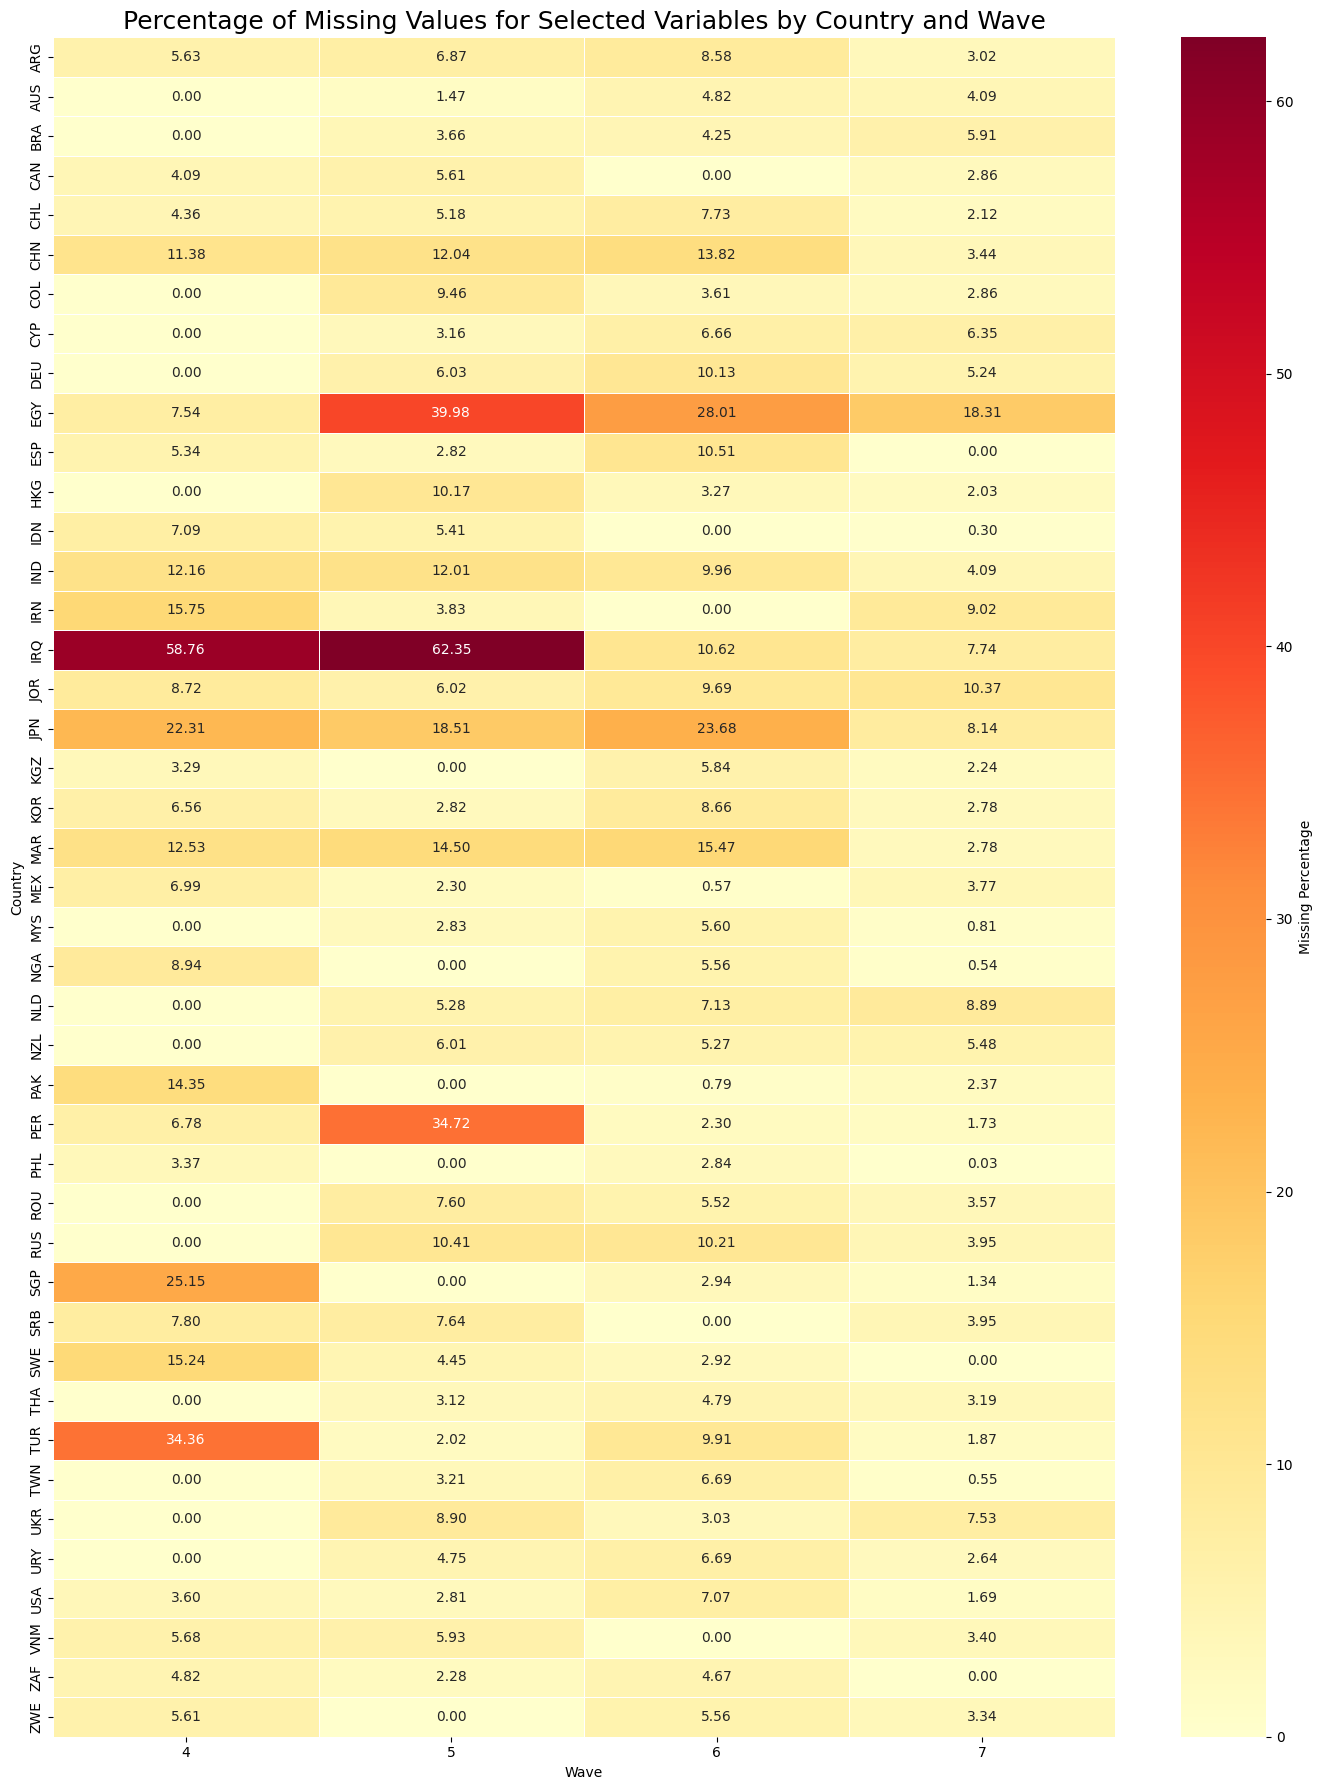

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# Load the iso_country_map JSON file
with open("iso_country.json", "r", encoding="utf-8") as file:
    iso_country_map = json.load(file)

# Calculate missing percentage for each (country, wave)
def missing_percentage(group):
    total_values = group.shape[0] * group.shape[1]
    negative_values = (group.select_dtypes(include='number') < 0).sum().sum()
    return (negative_values / total_values) * 100

# Group by country and wave, then compute missing percentage
missing_percentage_matrix = df_selected.groupby(["country", "wave"]).apply(missing_percentage).unstack(fill_value=0)

# Plot the heatmap
plt.figure(figsize=(14, 18))
sns.heatmap(
    missing_percentage_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Missing Percentage'}
)

plt.title("Percentage of Missing Values for Selected Variables by Country and Wave", fontsize=18)
plt.xlabel("Wave")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## Presence of Countries per Wave

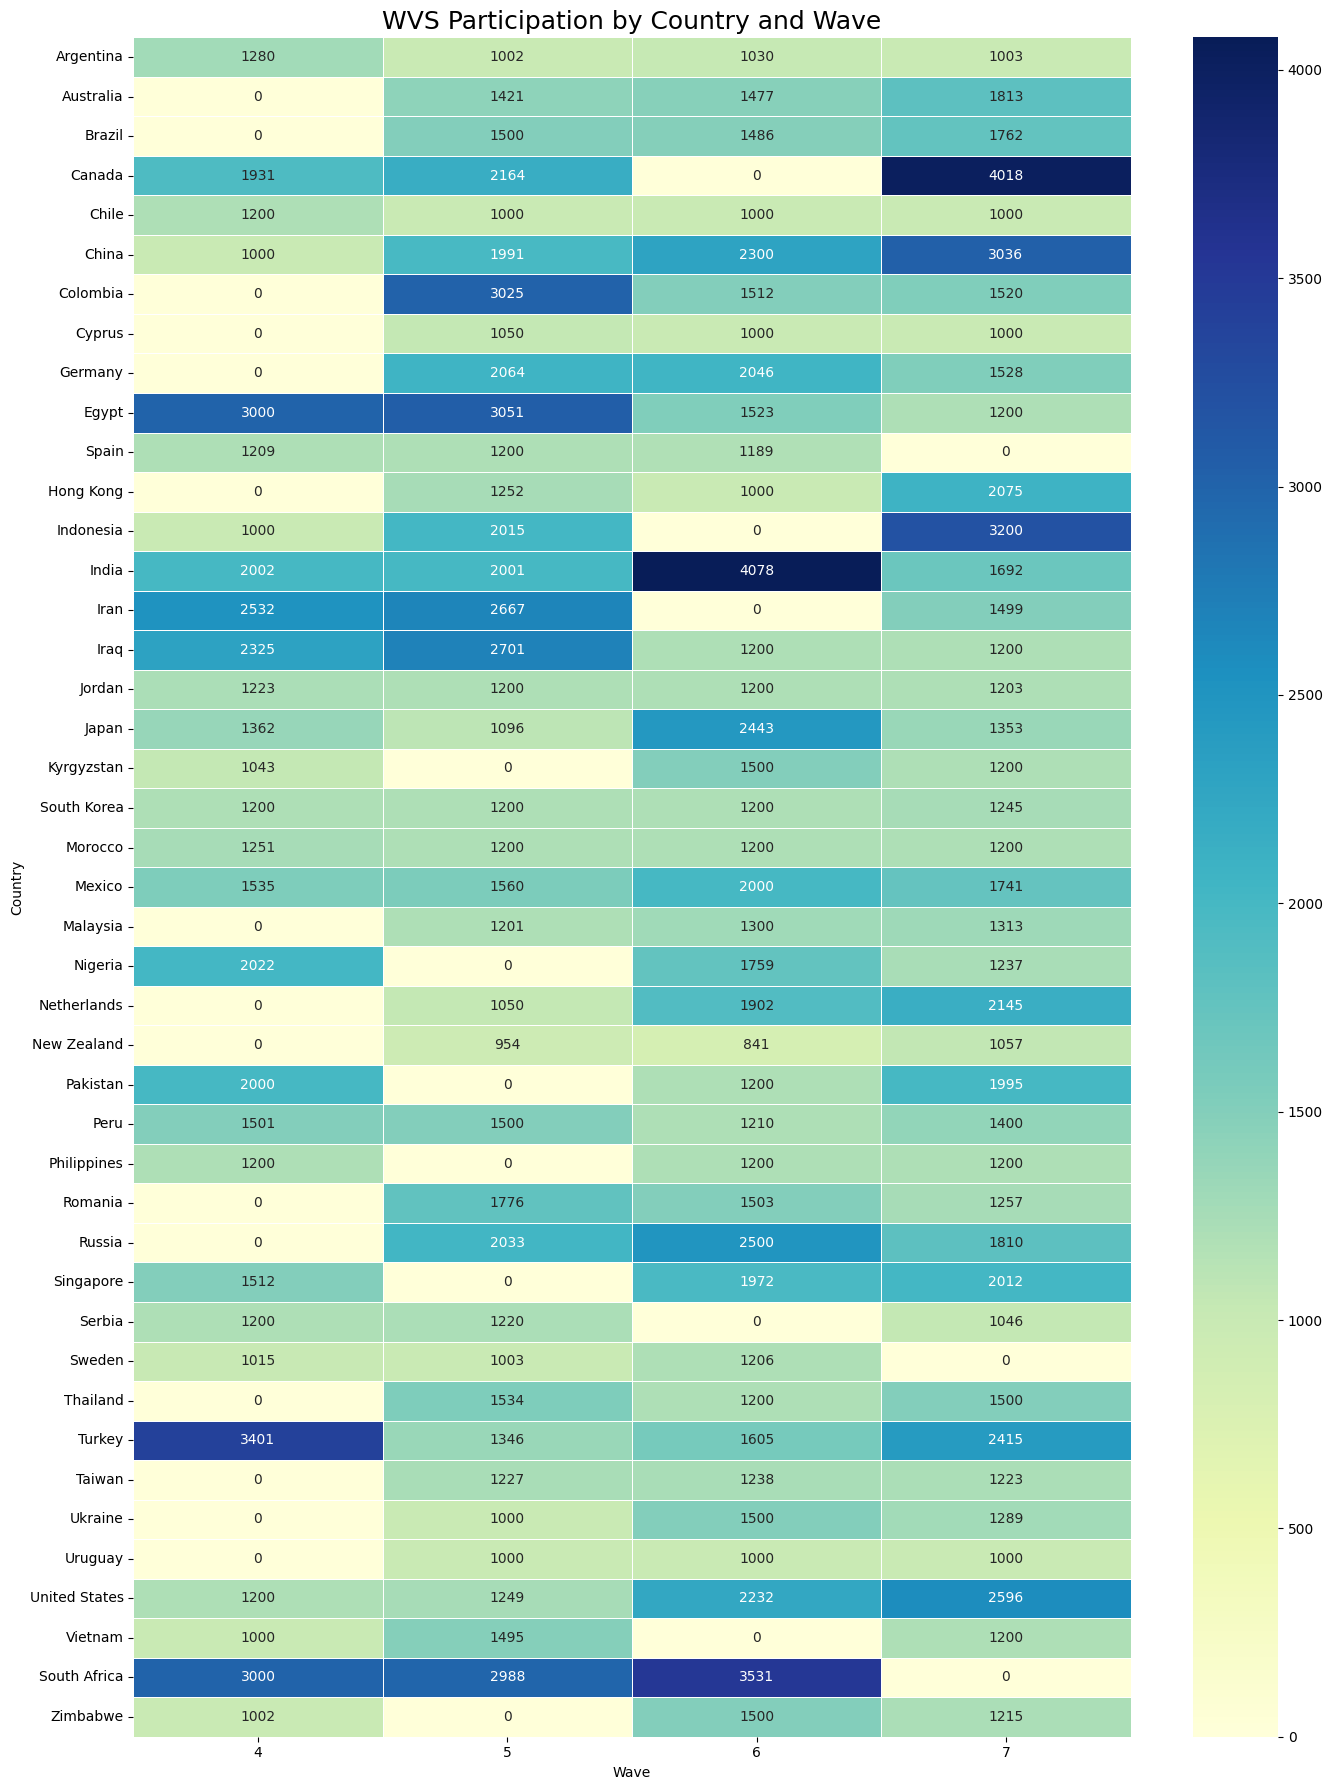

In [8]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# Load the pre-filtered data with waves 4 to 7
df = pd.read_csv('../data/processed/1_dataprep/wvs_filtered_waves4to7.csv')

# Create participation matrix (number of respondents per country per wave)
participation_matrix = df.groupby(["country", "wave"]).size().unstack(fill_value=0)

# Load ISO to full country name mapping from JSON
with open("iso_country.json", "r", encoding="utf-8") as f:
    iso_to_full = json.load(f)

# Map ISO codes to full country names
participation_matrix["Country Name"] = participation_matrix.index.map(iso_to_full)
participation_matrix = participation_matrix.set_index("Country Name")

# Step 4: Plot the heatmap
plt.figure(figsize=(14, 18))
sns.heatmap(participation_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title("WVS Participation by Country and Wave", fontsize=18)
plt.xlabel("Wave")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Exploring demographics

### Age

<Figure size 1200x800 with 0 Axes>

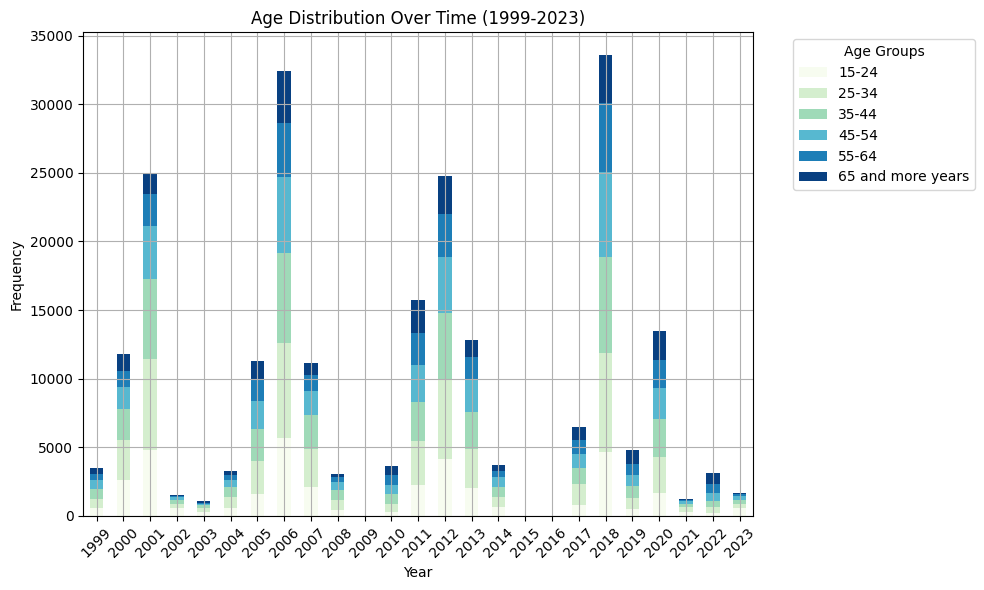

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


# Relabeling of intervals
value_labels = {
    1: "15-24",
    2: "25-34",
    3: "35-44",
    4: "45-54",
    5: "55-64",
    6: "65 and more years",
    -1: "Don't know",
    -2: "No answer",
    -4: "Not asked",
    -5: "Other missing; Multiple answers Mail (EVS)"
}

# Replace the values with the labels
df_selected["age_6"] = df_selected["age_6"].replace(value_labels)

# Drop missing values for X003R (including labels -1, -2, -4, -5)
df_wvs_clean = df_selected[~df_selected["age_6"].isin(["Don't know", "No answer", "Not asked", "Other missing; Multiple answers Mail (EVS)"])]

# Ensure that all years from 1989 to 2023 are included, even if some years have no data
years_range = list(range(1999, 2024))

# Group by year  and age interval  and calculate the counts
age_distribution_by_year = df_wvs_clean.groupby(['year', 'age_6']).size().unstack(fill_value=0)

# Reindex to ensure all years from 1989 to 2023 are included, filling missing years with 0 counts
age_distribution_by_year = age_distribution_by_year.reindex(years_range, fill_value=0)

# Plot the distribution of age intervals over time (1989-2023)
plt.figure(figsize=(12, 8))
age_distribution_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='GnBu')

# Adding labels and title
plt.title("Age Distribution Over Time (1999-2023)")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.legend(title="Age Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()  # Adjusting labels for them not to be cut off

# Show the plot
plt.show()

/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_45649/2119408911.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_distribution_by_year_group = df_selected.groupby(['Year_Group', 'age_6']).size().unstack(fill_value=0)


<Figure size 1200x800 with 0 Axes>

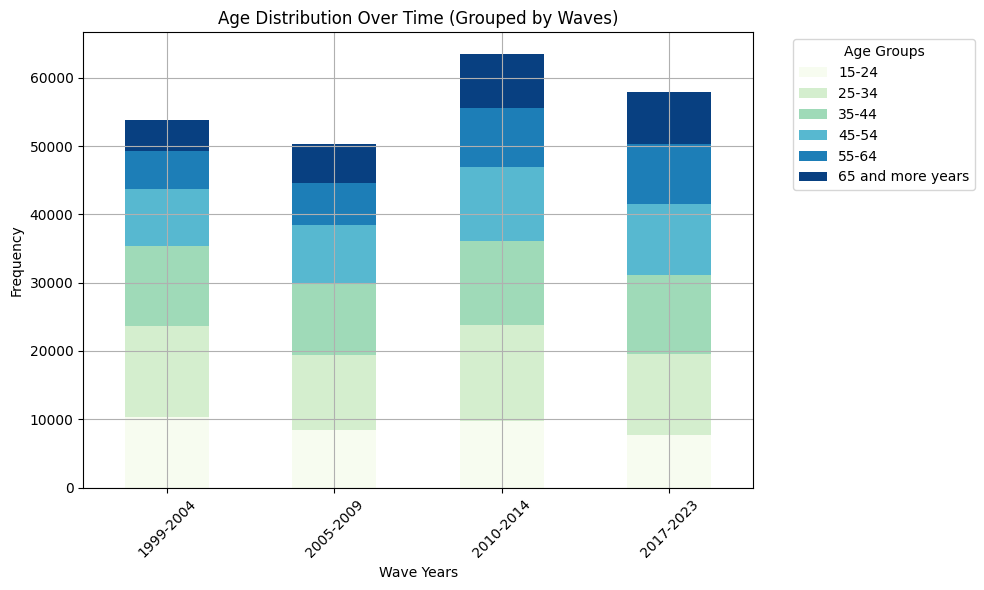

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Relabeling of intervals
value_labels = {
    1: "15-24",
    2: "25-34",
    3: "35-44",
    4: "45-54",
    5: "55-64",
    6: "65 and more years",
    -1: "Don't know",
    -2: "No answer",
    -4: "Not asked",
    -5: "Other missing; Multiple answers Mail (EVS)"
}

# Replace the values with the labels
df_selected["age_6"] = df_selected["age_6"].replace(value_labels)

# Drop missing values for X003R (including labels -1, -2, -4, -5)
df_selected = df_selected[~df_selected["age_6"].isin(["Don't know", "No answer", "Not asked", "Other missing; Multiple answers Mail (EVS)"])]

# Define the year intervals by waves 4 to 7

year_bins = [1999, 2005, 2010, 2017, 2023]  # waves 4 to 7
year_labels = ["1999-2004", "2005-2009", "2010-2014", "2017-2023"]  # Labels match the number of bins - 1

# Group years into bins
df_selected['Year_Group'] = pd.cut(df_selected['year'], bins=year_bins, labels=year_labels, right=True)

# Group by year range and age interval (X003R) and calculate the counts
age_distribution_by_year_group = df_selected.groupby(['Year_Group', 'age_6']).size().unstack(fill_value=0)

# Plot the distribution of age intervals over time (1999-2023) by grouped years
plt.figure(figsize=(12, 8))
age_distribution_by_year_group.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='GnBu')

# Adding labels and title
plt.title("Age Distribution Over Time (Grouped by Waves)")
plt.xlabel("Wave Years")
plt.ylabel("Frequency")

# Adding legend and grid
plt.legend(title="Age Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()  # To adjust layout so labels don't get cut off

# Show the plot
plt.show()


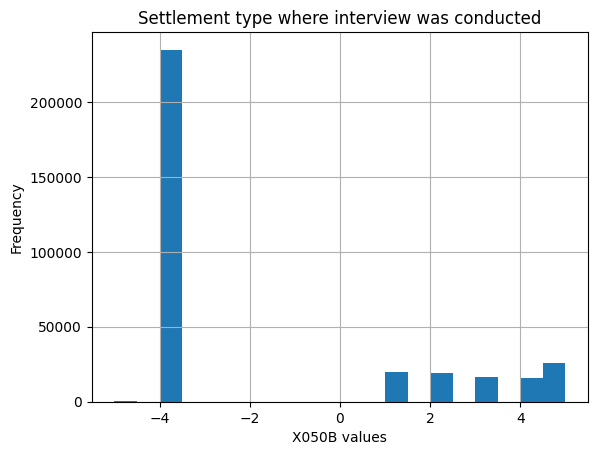

In [38]:
df_wvs["X050B"].hist(bins=20)
plt.title("Settlement type where interview was conducted")
plt.xlabel("X050B values")
plt.ylabel("Frequency")
plt.show()

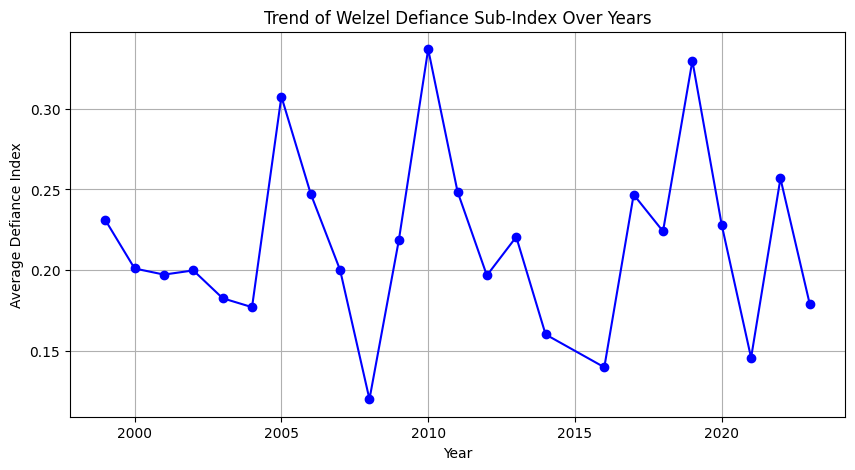

In [41]:
# Mean of Defiance Index per year
yearly_avg = df_wvs.groupby("S020")["Y011"].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', linestyle='-', color='b')
plt.xlabel("Year")
plt.ylabel("Average Defiance Index")
plt.title("Trend of Welzel Defiance Sub-Index Over Years")
plt.grid(True)

plt.show()

In [42]:
# Group by year and calculate the average for each sub-index
avg_defiance_by_year = df_wvs.groupby("S020")["Y011"].mean()
avg_skepticism_by_year = df_wvs.groupby("S020")["Y014"].mean()

# Year with the highest and lowest average for Defiance (Y011)
max_defiance_year = avg_defiance_by_year.idxmax()
min_defiance_year = avg_defiance_by_year.idxmin()

# Year with the highest and lowest average for Skepticism (Y014)
max_skepticism_year = avg_skepticism_by_year.idxmax()
min_skepticism_year = avg_skepticism_by_year.idxmin()

# Output the results
print(f"Year with highest defiance (Y011): {max_defiance_year}")
print(f"Year with lowest defiance (Y011): {min_defiance_year}")
print(f"Year with highest skepticism (Y014): {max_skepticism_year}")
print(f"Year with lowest skepticism (Y014): {min_skepticism_year}")

Year with highest defiance (Y011): 2010
Year with lowest defiance (Y011): 2008
Year with highest skepticism (Y014): 2016
Year with lowest skepticism (Y014): 2023


In [43]:
# Group by country and average for each sub-index
avg_defiance_by_country = df_wvs.groupby("COUNTRY_ALPHA")["Y011"].mean()
avg_skepticism_by_country = df_wvs.groupby("COUNTRY_ALPHA")["Y014"].mean()

# Top 10 countries with the highest and lowest average for Defiance (Y011)
top_10_defiance_high = avg_defiance_by_country.nlargest(10)
top_10_defiance_low = avg_defiance_by_country.nsmallest(10)

# Get the top 10 countries with the highest and lowest average for Skepticism (Y014)
top_10_skepticism_high = avg_skepticism_by_country.nlargest(10)
top_10_skepticism_low = avg_skepticism_by_country.nsmallest(10)

# Output the results
print("Top 10 countries with the highest defiance (Y011):")
print(top_10_defiance_high)

print("\nTop 10 countries with the lowest defiance (Y011):")
print(top_10_defiance_low)

print("\nTop 10 countries with the highest skepticism (Y014):")
print(top_10_skepticism_high)

print("\nTop 10 countries with the lowest skepticism (Y014):")
print(top_10_skepticism_low)

Top 10 countries with the highest defiance (Y011):
COUNTRY_ALPHA
JPN    0.567801
SWE    0.463254
TWN    0.445704
HKG    0.437364
NOR    0.431002
MAC    0.427560
KOR    0.426767
CHE    0.401988
FIN    0.398795
EST    0.395044
Name: Y011, dtype: float64

Top 10 countries with the lowest defiance (Y011):
COUNTRY_ALPHA
QAT    0.013440
GHA    0.054183
UZB    0.073355
ECU    0.076818
LBY    0.077880
JOR    0.079227
PRI    0.079840
YEM    0.090099
TTO    0.094672
BGD    0.095527
Name: Y011, dtype: float64

Top 10 countries with the highest skepticism (Y014):
COUNTRY_ALPHA
HTI    0.799867
BOL    0.684665
PER    0.675735
NIC    0.668142
ARG    0.661035
GTM    0.649895
VEN    0.617579
YEM    0.613404
MDA    0.584597
MEX    0.581776
Name: Y014, dtype: float64

Top 10 countries with the lowest skepticism (Y014):
COUNTRY_ALPHA
QAT    0.111048
JOR    0.181463
VNM    0.190658
UZB    0.191661
TJK    0.255875
FIN    0.285948
CHN    0.287532
TZA    0.287780
TUR    0.304454
KWT    0.305726
Name: Y014, dt

## Variables of interest

In [44]:
import pandas as pd
import numpy as np

# Function to normalize (multi-point scale 0 to 1)
def multi_scale(value):
    if value == 1:
        return 1.0  # Very important
    elif value == 2:
        return 0.67  # Rather important
    elif value == 3:
        return 0.33  # Not very important
    elif value == 4:
        return 0.0  # Not at all important
    else:
        return np.nan  # Invalid or missing values

# Apply the normalization to both A001 and A002
df_wvs['norm_A001'] = df_wvs['A001'].apply(multi_scale)
df_wvs['norm_A002'] = df_wvs['A002'].apply(multi_scale)

# Create the "importance_close_circle" by averaging the normalized values of A001 and A002
df_wvs['importance_close_circle'] = df_wvs[['norm_A001', 'norm_A002']].mean(axis=1)

# Inspect the first few rows of the new indicator
print(df_wvs[['A001', 'A002', 'importance_close_circle']].head(100))

      A001  A002  importance_close_circle
999      1     1                    1.000
1000     1     2                    0.835
1001     1     2                    0.835
1002     1     3                    0.665
1003     1     2                    0.835
...    ...   ...                      ...
1094     1     3                    0.665
1095     1     1                    1.000
1096     1     1                    1.000
1097     1     2                    0.835
1098     1     2                    0.835

[100 rows x 3 columns]


/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_28178/1181796519.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wvs['norm_A001'] = df_wvs['A001'].apply(multi_scale)
/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_28178/1181796519.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wvs['norm_A002'] = df_wvs['A002'].apply(multi_scale)
/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_28178/1181796519.py:22: SettingWithCopyWarning: 
A value is trying to be set on a c

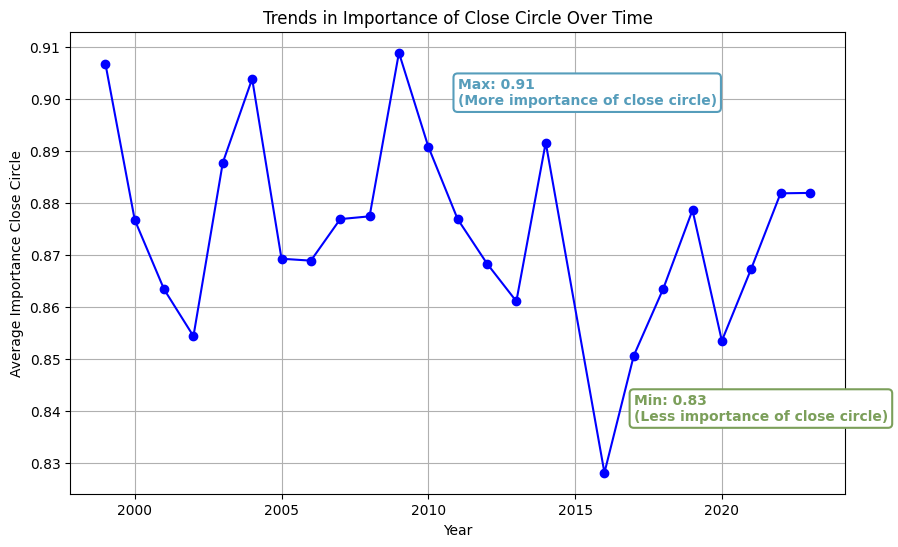

In [45]:
# Group by year and calculate the mean of importance_close_circle
yearly_trends = df_wvs.groupby('S020')['importance_close_circle'].mean()

# Identify the years with the highest and lowest values
max_year = yearly_trends.idxmax()  # Year with the highest value
min_year = yearly_trends.idxmin()  # Year with the lowest value

max_value = yearly_trends.max()  # Highest value of the Importance Close Circle
min_value = yearly_trends.min()  # Lowest value of the Importance Close Circle

# Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_trends.index, yearly_trends.values, marker='o', linestyle='-', color='b')
plt.title("Trends in Importance of Close Circle Over Time")
plt.xlabel("Year")
plt.ylabel("Average Importance Close Circle")
plt.grid(True)

# Add labels with styled text boxes for the highest and lowest points
plt.annotate(f"Max: {max_value:.2f}\n(More importance of close circle)", 
             xy=(max_year, max_value), 
             xytext=(max_year + 2, max_value -0.01),  # Adjust text position
             bbox=dict(facecolor='white', edgecolor='#569dbb', boxstyle="round,pad=0.3", lw=1.5),
             fontsize=10, color='#569dbb', fontweight='bold')

plt.annotate(f"Min: {min_value:.2f}\n(Less importance of close circle)", 
             xy=(min_year, min_value), 
             xytext=(min_year + 1, min_value + 0.01),  # Adjust text position
             bbox=dict(facecolor='white', edgecolor='#7b9f5a', boxstyle="round,pad=0.3", lw=1.5),
             fontsize=10, color='#7b9f5a', fontweight='bold')

plt.show()

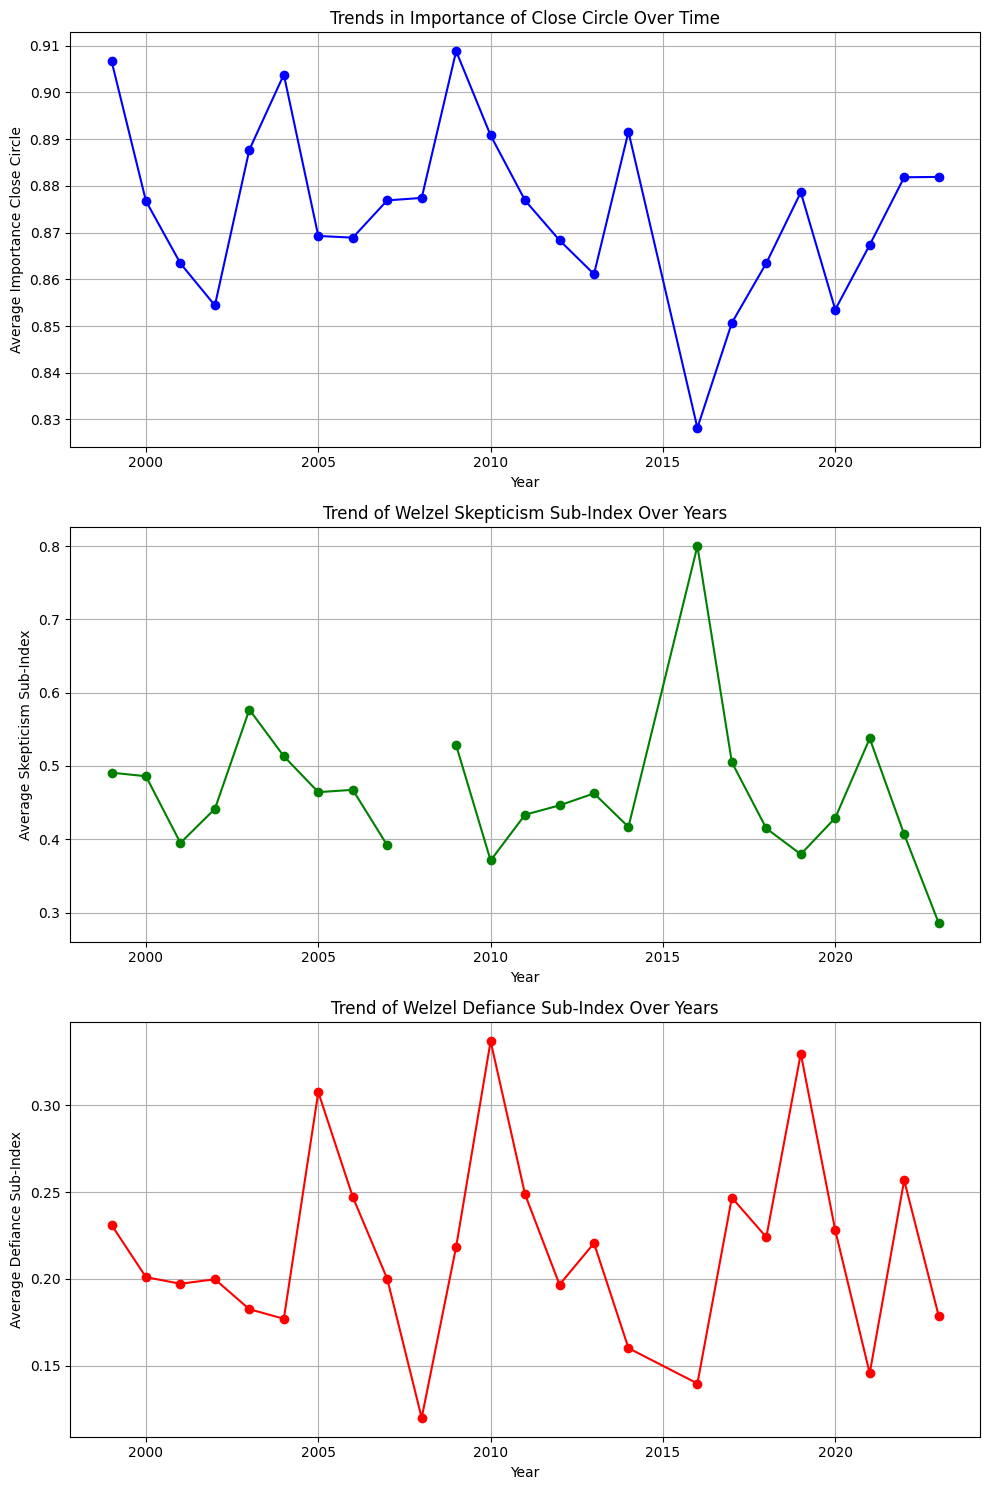

In [46]:
import matplotlib.pyplot as plt

# Group by year and calculate the mean of importance_close_circle, Y014 (Skepticism), and Y011 (Defiance)
importance_trends = df_wvs.groupby('S020')['importance_close_circle'].mean()
skepticism_trends = df_wvs.groupby('S020')['Y014'].mean()  # Skepticism Sub-Index
defiance_trends = df_wvs.groupby('S020')['Y011'].mean()  # Defiance Sub-Index

# Create the figure and axes for the subplots
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot the Importance of Close Circle
ax[0].plot(importance_trends.index, importance_trends.values, marker='o', linestyle='-', color='b')
ax[0].set_title("Trends in Importance of Close Circle Over Time")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Importance Close Circle")
ax[0].grid(True)

# Plot the Trend of Welzel Skepticism Sub-Index
ax[1].plot(skepticism_trends.index, skepticism_trends.values, marker='o', linestyle='-', color='g')
ax[1].set_title("Trend of Welzel Skepticism Sub-Index Over Years")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Average Skepticism Sub-Index")
ax[1].grid(True)

# Plot the Trend of Welzel Defiance Sub-Index
ax[2].plot(defiance_trends.index, defiance_trends.values, marker='o', linestyle='-', color='r')
ax[2].set_title("Trend of Welzel Defiance Sub-Index Over Years")
ax[2].set_xlabel("Year")
ax[2].set_ylabel("Average Defiance Sub-Index")
ax[2].grid(True)

# Adjust the layout for better spacing
plt.tight_layout()
plt.show()

## Correlations

Pearson Correlation between Importance Close Circle and Skepticism: -0.32


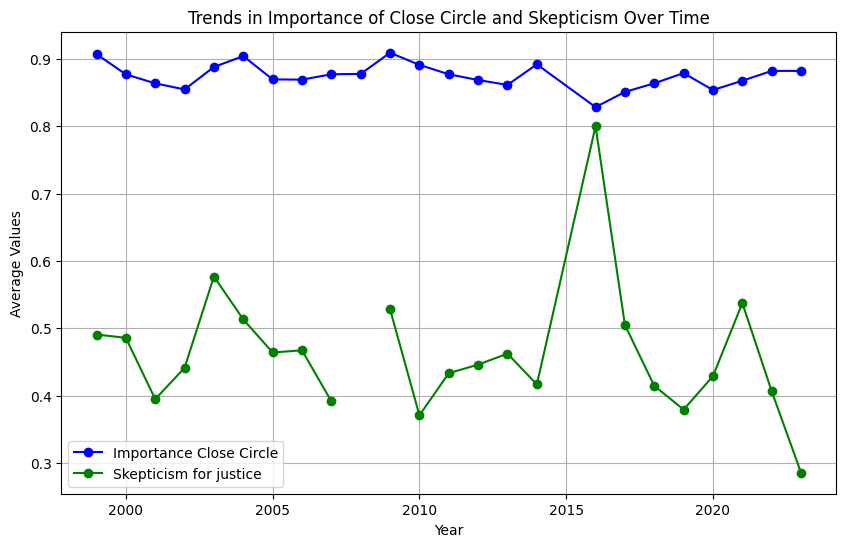

In [47]:
# Group by year and calculate the mean of Importance Close Circle and Skepticism
importance_trends = df_wvs.groupby('S020')['importance_close_circle'].mean()
yearly_avg_skepticism = df_wvs.groupby("S020")["Y014"].mean()  # Mean Skepticism Index per year

# Calculate the Pearson correlation between Importance Close Circle and Skepticism
correlation = importance_trends.corr(yearly_avg_skepticism)

# Print the correlation value
print(f"Pearson Correlation between Importance Close Circle and Skepticism: {correlation:.2f}")

# Plot the two trends to visually inspect the relationship
plt.figure(figsize=(10, 6))
plt.plot(importance_trends.index, importance_trends.values, label='Importance Close Circle', color='b', marker='o')
plt.plot(yearly_avg_skepticism.index, yearly_avg_skepticism.values, label='Skepticism for justice', color='g', marker='o')

# Add labels, title, and legend
plt.title("Trends in Importance of Close Circle and Skepticism Over Time")
plt.xlabel("Year")
plt.ylabel("Average Values")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

Pearson Correlation between Importance Close Circle and Defiance: 0.13


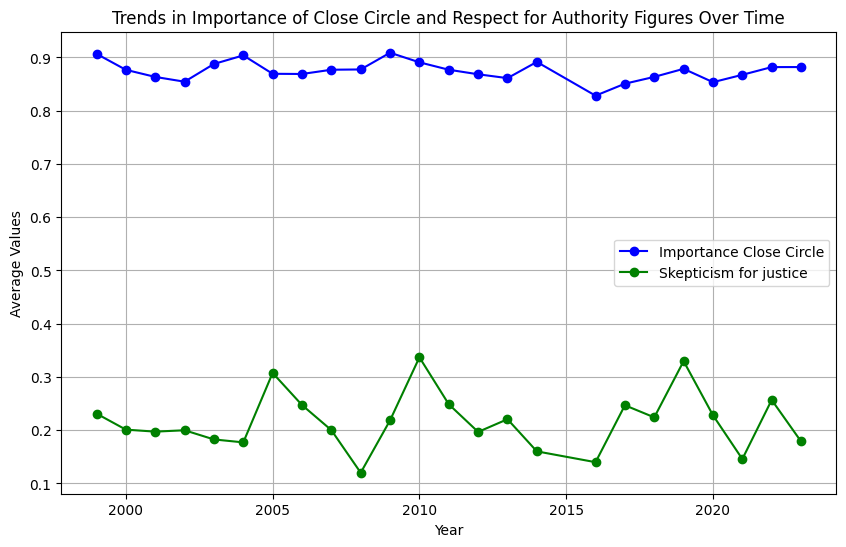

In [48]:
# Group by year and calculate the mean of Importance Close Circle and Skepticism
importance_trends = df_wvs.groupby('S020')['importance_close_circle'].mean()
authority_respect = df_wvs.groupby("S020")["Y011"].mean()  # Mean Skepticism Index per year

# Calculate the Pearson correlation between Importance Close Circle and Respect for authority
correlation = importance_trends.corr(authority_respect)

# Print the correlation value
print(f"Pearson Correlation between Importance Close Circle and Defiance: {correlation:.2f}")

# Plot the two trends to visually inspect the relationship
plt.figure(figsize=(10, 6))
plt.plot(importance_trends.index, importance_trends.values, label='Importance Close Circle', color='b', marker='o')
plt.plot(authority_respect.index, authority_respect.values, label='Skepticism for justice', color='g', marker='o')

# Add labels, title, and legend
plt.title("Trends in Importance of Close Circle and Respect for Authority Figures Over Time")
plt.xlabel("Year")
plt.ylabel("Average Values")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()